# Bootstrapping

In modern statistics, the bootstrap has become the standard way to estimate standard error.

1. it can be used for virtually any statistic and
2. does not rely on any distributional assumptions (such as data being normally distributed)

Data scientists would use this information:

- not to publish a scholarly paper or submit a result to a regulatory agency (as a researcher might)
- but most likely to communicate the potential error in an estimate, and perhaps **to learn whether a larger sample is needed**.

In [1]:
import numpy as np
import pandas as pd

## The Bootstrapping Procedure

A step-by-step breakdown of the bootstrapping procedure that returns:

1. mean of bootstrap means
2. standard error `se`
3. confidence interval `(ci_lower, ci_upper)`

In [ ]:
from utils import bootstraps_mean

For reference see [scipy.stats.bootstrap](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.bootstrap.html) and it's [source code](https://github.com/scipy/scipy/blob/cadff2794c526d283f0c048e3c19d8b960d9e415/scipy/stats/_resampling.py#L300) implementation.

### Apply on adults `hours-per-week` numerical value

In [3]:
from pathlib import Path

data_path = Path('../data/adult.csv')
data_path.exists()

True

In [4]:
df_raw = pd.read_csv(data_path)
df = df_raw[['hours-per-week', 'age']]
df

,hours-per-week,age
0,40,39
1,13,50
2,40,38
3,40,53
4,40,28
...,...,...
32556,38,27
32557,40,40
32558,40,58
32559,20,22


### Set `trace=True` to see how the procedure executes

In [5]:
mean, se, ci = bootstraps_mean(df['hours-per-week'], n_resamples=10000, confidence_level=95, trace=True)

Bootstrapping 10000 samples...
Bootstrapped 0 samples...
Bootstrapped 100 samples...
Bootstrapped 200 samples...
Bootstrapped 300 samples...
Bootstrapped 400 samples...
Bootstrapped 500 samples...
Bootstrapped 600 samples...
Bootstrapped 700 samples...
Bootstrapped 800 samples...
Bootstrapped 900 samples...
Bootstrapped 1000 samples...
Bootstrapped 1100 samples...
Bootstrapped 1200 samples...
Bootstrapped 1300 samples...
Bootstrapped 1400 samples...
Bootstrapped 1500 samples...
Bootstrapped 1600 samples...
Bootstrapped 1700 samples...
Bootstrapped 1800 samples...
Bootstrapped 1900 samples...
Bootstrapped 2000 samples...
Bootstrapped 2100 samples...
Bootstrapped 2200 samples...
Bootstrapped 2300 samples...
Bootstrapped 2400 samples...
Bootstrapped 2500 samples...
Bootstrapped 2600 samples...
Bootstrapped 2700 samples...
Bootstrapped 2800 samples...
Bootstrapped 2900 samples...
Bootstrapped 3000 samples...
Bootstrapped 3100 samples...
Bootstrapped 3200 samples...
Bootstrapped 3300 sample

## Plot Bootstrap Distribution to Understand it Visually

- Left: distribution of the variable (`age`) itself
- Right: distribution of the statistic (`mean_age`) for `n_resamples=999`

In [6]:
_, se, _, bootstrap_means = bootstraps_mean(df['age'], n_resamples=999, confidence_level=95, return_bootstrap_means=True)

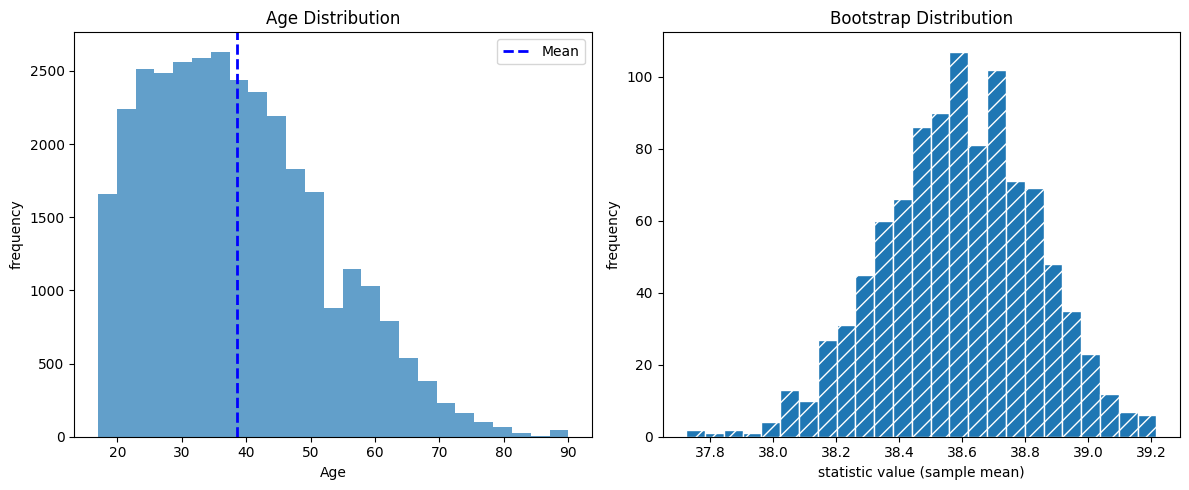

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Plot Age distribution itself
axes[0].hist(df['age'], bins=25, alpha=0.7)
axes[0].axvline(df['age'].mean(), color='blue', linestyle='dashed', linewidth=2, label='Mean')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('frequency')
axes[0].legend()

# 2. Plot bootstrap distribution (keep as is)
axes[1].hist(bootstrap_means, bins=25, hatch='//', edgecolor='white')
axes[1].set_title('Bootstrap Distribution')
axes[1].set_xlabel('statistic value (sample mean)')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

### Standard Deviation vs. Versus Standard Error

Do not confuse standard deviation (which measures the variability of individual data points) with standard error (which measures the variability of a sample metric).

In [ ]:
print(f"Standard Error is about mean_age statistic: {se:0.2f}")
print(f"Standard Deviation is about age variable: {df['age'].std():0.2f}")

Standard Error of the mean_age statistic: 0.24
Standard Deviation of the age variable: 13.64


## Statistical Power

### How to use it:

- **Increase Effect Size:** Watch the green curve pull away from the blue curve, drastically increasing power.
    
- **Increase Sample Size:** Watch both curves get instantly taller and narrower (less variance), making the overlap shrink and power shoot up.
    
- **Increase Std Dev:** Watch the curves flatten out and blur together (more noise), causing your power to drop.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from ipywidgets import interact, FloatSlider, IntSlider

%matplotlib inline

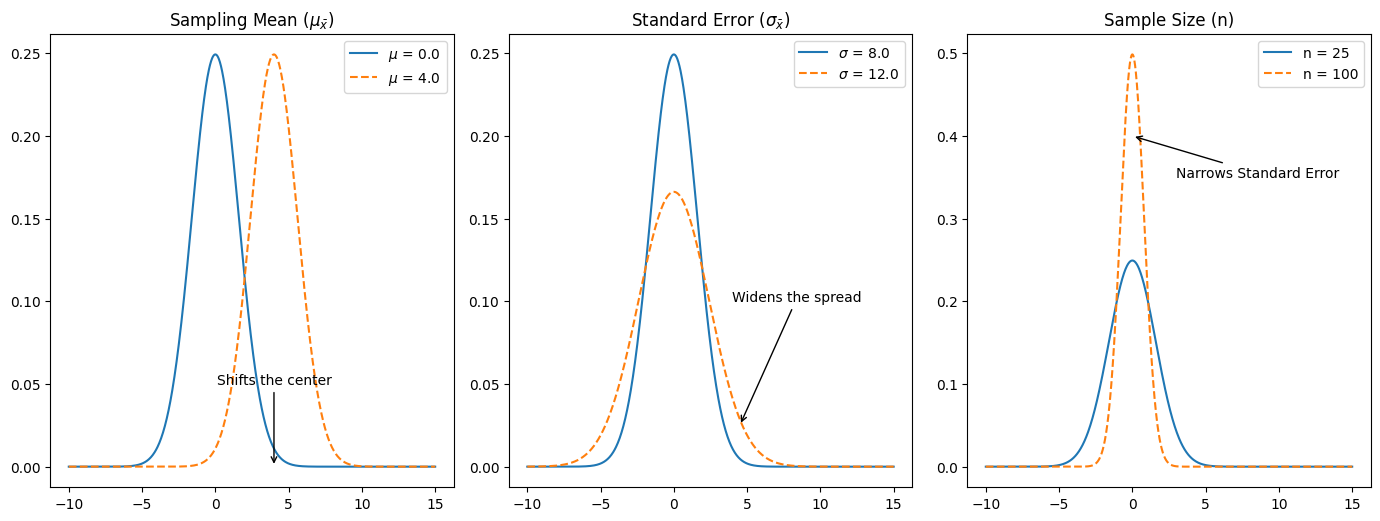

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

def plot_static_power_analysis():
    # --- Independent Parameters ---
    # Distribution 1 (Null)
    mu_0, sigma_0, n_0 = 0.0, 8.0, 25
    se_0 = sigma_0 / np.sqrt(n_0)
    
    # Distribution 2 (Alternative)
    mu_a, sigma_a, n_a = 4.0, 8.0, 25
    se_a = sigma_a / np.sqrt(n_a)
    
    alpha = 0.05
    
    # --- Figure Setup ---
    fig = plt.figure(figsize=(14, 10))
    x = np.linspace(-10, 15, 1000)

    # --- ROW 1: Singular Distribution Effects ---
    # 1. Changing the Mean
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(x, stats.norm.pdf(x, mu_0, se_0), label=f'$\\mu$ = {mu_0}')
    ax1.plot(x, stats.norm.pdf(x, mu_0 + 4, se_0), '--', label=f'$\\mu$ = {mu_0 + 4}')
    ax1.annotate("Shifts the center", xy=(4.0, 0), xytext=(4, 0.05), arrowprops=dict(arrowstyle="->"), ha='center')
    ax1.set_title(r"Sampling Mean ($\mu_\bar{x}$)")
    ax1.legend()

    # 2. Changing the Standard Error
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(x, stats.norm.pdf(x, mu_0, se_0), label=f'$\\sigma$ = {sigma_0}')
    ax2.plot(x, stats.norm.pdf(x, mu_0, (sigma_0 * 1.5) / np.sqrt(n_0)), '--', label=f'$\\sigma$ = {sigma_0 * 1.5}')
    ax2.annotate("Widens the spread", xy=(4.5, 0.025), xytext=(4, 0.1), arrowprops=dict(arrowstyle="->"))
    ax2.set_title(r"Standard Error ($\sigma_\bar{x}$)")
    ax2.legend()

    # 3. Changing the Sample Size
    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(x, stats.norm.pdf(x, mu_0, se_0), label=f'n = {n_0}')
    ax3.plot(x, stats.norm.pdf(x, mu_0, sigma_0 / np.sqrt(n_0 * 4)), '--', label=f'n = {n_0 * 4}')
    ax3.annotate("Narrows Standard Error", xy=(0, 0.4), xytext=(3, 0.35), arrowprops=dict(arrowstyle="->"))
    ax3.set_title("Sample Size (n)")
    ax3.legend()

    plt.tight_layout()
    plt.show()

# Execute the updated plot
plot_static_power_analysis()

In [ ]:
    # --- ROW 2: Combined Distributions ---
    # ax4 = plt.subplot(2, 1, 2)
    
    # null_curve = stats.norm.pdf(x, mu_0, se_0)
    # alt_curve = stats.norm.pdf(x, mu_a, se_a)
    
    # critical_value = stats.norm.ppf(1 - alpha, mu_0, se_0)
    # power = 1 - stats.norm.cdf(critical_value, mu_a, se_a)
    
    # ax4.plot(x, null_curve, color='blue', linewidth=2, label='Null Hypothesis ($H_0$)')
    # ax4.plot(x, alt_curve, color='green', linewidth=2, label='Alternative Hypothesis ($H_a$)')
    # ax4.axvline(critical_value, color='red', linestyle='--', label=f'Critical Value ($\\alpha$={alpha})')
    
    # # Shade Power Region
    # x_fill = np.linspace(critical_value, 15, 500)
    # ax4.fill_between(x_fill, stats.norm.pdf(x_fill, mu_a, se_a), color='green', alpha=0.3)
    
    # # Annotations
    # ax4.annotate(f'Power Area: {power:.1%}\n(Probability of correctly rejecting $H_0$)', 
    #              xy=(critical_value + 1.5, 0.05), xytext=(critical_value + 3, 0.15),
    #              arrowprops=dict(arrowstyle='->', lw=1.5))
    
    # ax4.set_title('Null vs Alternative Distribution', fontsize=14, fontweight='bold')
    # ax4.set_xlabel('Sample Mean')
    # ax4.set_ylabel('Density')
    # ax4.legend(loc='upper right')
    # ax4.grid(True, alpha=0.3)